In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

In this notebook, we will observe the effect of using stochastic gradient descent, rather than full gradient descent.

For this, we will generate synthetic data which is linear.
The reason is that this system is simple to visualize.

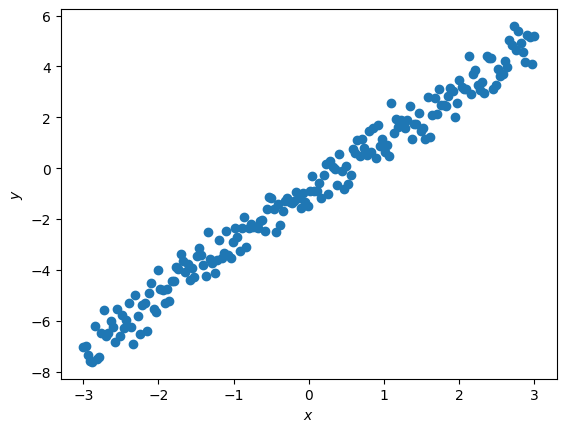

In [2]:
rng = torch.Generator().manual_seed(0)
X = torch.linspace(-3, 3, 200).unsqueeze(1)
true_w, true_b = 2.0, -1.0
y = true_w * X + true_b + 0.5 * torch.randn_like(X)

dataset = TensorDataset(X,y)

plt.scatter(X, y)
plt.ylabel(r"$y$")
plt.xlabel(r"$x$")
plt.show()

In fact, with only two parameters, we can plot the objective function at all possible combinations, quite like the decision function

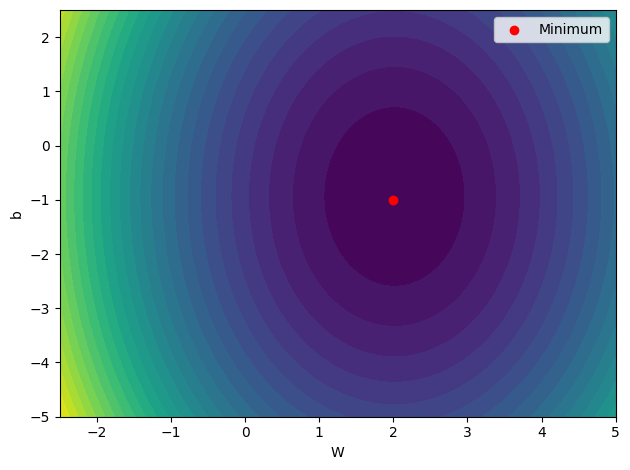

In [3]:
w_vals = np.linspace(-2.5, 5., 200)
b_vals = np.linspace(-5., 2.5, 200)
ww, bb = np.meshgrid(w_vals, b_vals)
Z = np.zeros_like(ww)

for i in range(ww.shape[0]):
    for j in range(ww.shape[1]):
        w = ww[i, j]
        b = bb[i, j]
        y_hat = w * X.numpy() + b
        Z[i,j] = np.mean((y_hat - y.numpy())**2)

plt.contourf(ww, bb, Z, levels=30)
plt.scatter(true_w, true_b, c='r', label="Minimum")
plt.xlabel('W')
plt.ylabel("b")
plt.legend()
plt.tight_layout()

Next, we define a function taking a generic optimizer as an argument, and fits a linear model, with the desired batch size. 

Meanwhile, a history is kept, both for the loss and for the parameters, which is then plotted.

In [4]:
loss_fun = nn.MSELoss()

def eval_optimizer_trajectory(opt, epochs=50, batch_size=32, **kwargs):

    mod = nn.Linear(in_features=1, out_features=1)
    nn.init.constant_(mod.weight, 0.0)
    nn.init.constant_(mod.bias, 0.0)

    dataloader = DataLoader(dataset, batch_size=batch_size)
    optimizer = opt(mod.parameters(), **kwargs)

    # collector for the trajectory
    traj = []
    losses = []

    for _ in range(epochs):
        for batch_X, batch_y in dataloader:
            pred = mod(batch_X)
            loss = loss_fun(pred, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            traj.append(np.array([mod.state_dict()['weight'][0].numpy()[0], mod.state_dict()['bias'].numpy()[0]]))

    traj = np.array(traj)

    fig, axs = plt.subplots(1,2)
    axs[0].plot(losses)
    axs[0].set_xlabel("Iteration")
    axs[0].set_ylabel(r"$\mathcal{L}$")

    axs[1].contourf(ww, bb, Z, levels=30)
    axs[1].plot(traj[:,0], traj[:,1])
    axs[1].scatter(true_w, true_b, c='r', label="Minimum")
    axs[1].set_xlabel('W')
    axs[1].set_ylabel("b")
    axs[1].legend()

    plt.tight_layout()

You can use the function defined above as follows.

Setting batch_size to be 1, we obtain SGD:

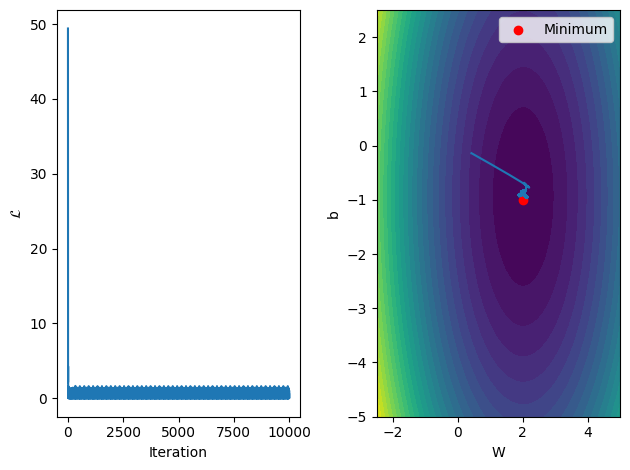

In [5]:
eval_optimizer_trajectory(optim.SGD, batch_size=1, lr=1e-2)

Setting the batch size to the number of data points makes SGD behave as full GD.

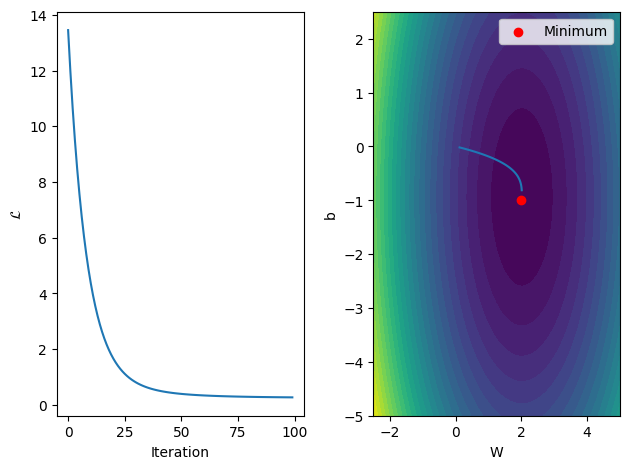

In [6]:
eval_optimizer_trajectory(optim.SGD, epochs=100, batch_size=200, lr=1e-2)

Any batch size between 1 and 200 is mini-batch SGD

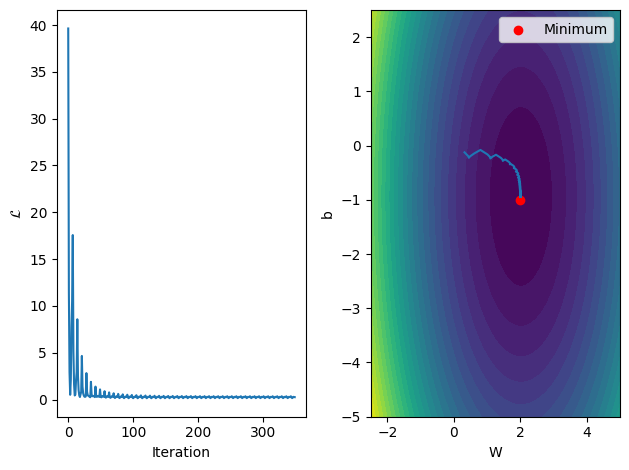

In [7]:
eval_optimizer_trajectory(optim.SGD, batch_size=32, lr=1e-2)

Other parameters can be used too (https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html), for example momentum:

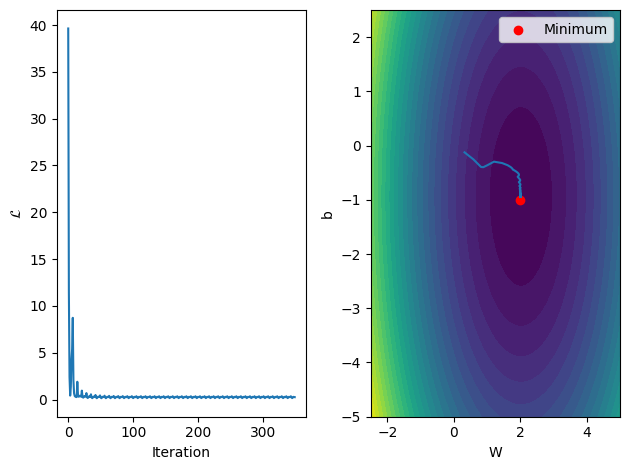

In [8]:
eval_optimizer_trajectory(optim.SGD, batch_size=32, lr=1e-2, momentum=0.5)

`weight_decay` is L2 regularization on the parameters

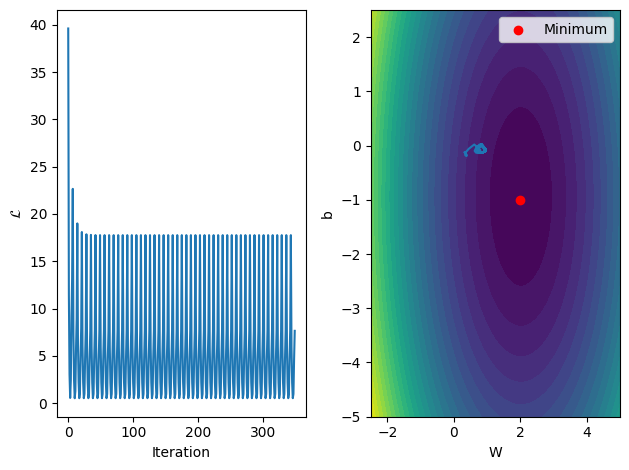

In [9]:
eval_optimizer_trajectory(optim.SGD, batch_size=32, lr=1e-2, weight_decay=10.0)

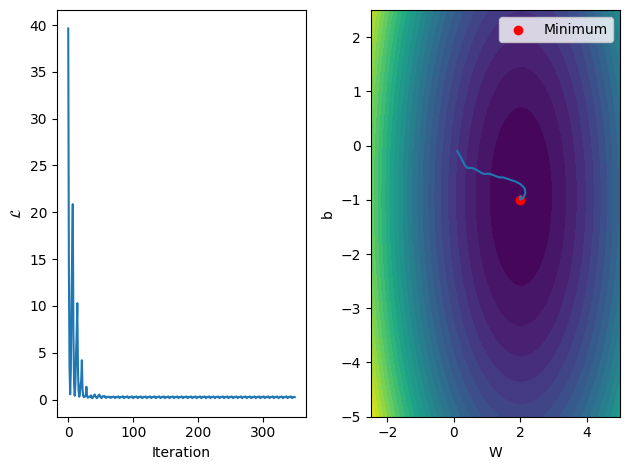

In [10]:
eval_optimizer_trajectory(optim.Adam, batch_size=32, lr=1e-1)

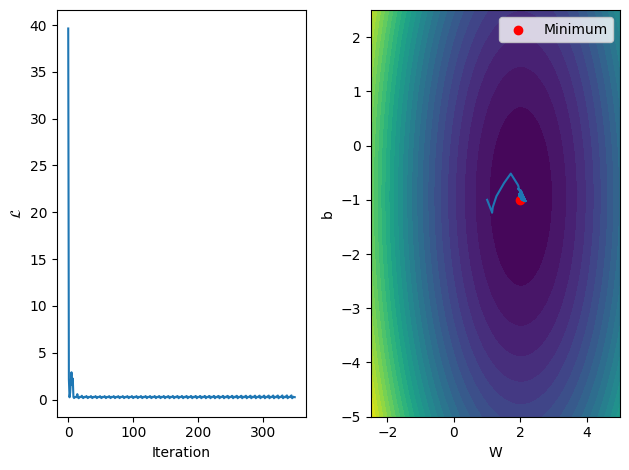

In [11]:
eval_optimizer_trajectory(optim.RMSprop, batch_size=32, lr=1e-1)